# Renewable Energy Output Prediction Using Artificial Neural Networks

Based on Negnevitsky — AI: A Guide to Intelligent Systems, Ch. 6

## Problem Statement
Accurate hourly energy-output forecasting helps improve solar planning, grid operations, and system sizing. This project trains an ANN to predict PV energy output (kWh) from weather and time-based inputs.

## Objectives
- Build a multilayer perceptron (MLP) with 2 hidden layers using TensorFlow/Keras
- Train the network using backpropagation on real-world hourly PV and weather data
- Predict PV energy output (kWh) from weather input features
- Compare ANN performance against a linear regression baseline
- Evaluate using RMSE, MAE, and R² metrics

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

OUTPUT_DIR = Path('artifacts')

# Weather and time-based feature columns (5 inputs)
FEATURE_COLUMNS = ['Air_Temp', 'Wind_Speed', 'Relative_Humidity', 'hour', 'month']
# Target column to predict (energy output in kWh)
TARGET_COLUMN = 'Energy_kWh'

EPOCHS = 150
BATCH_SIZE = 32
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15
LEARNING_RATE = 0.001
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load and preprocess data

The dataset is sorted by time, missing values are handled, and time features such as hour and month are extracted from the datetime column.

In [36]:
# The datasets are already provided in the Datasets folder.
dataset_folder = 'Datasets'
print(f"Dataset folder: {dataset_folder}")
import os
for file in os.listdir(dataset_folder):
    print(f"  - {file}")


Dataset folder: Datasets
  - DATARENER.csv
  - Humidity.csv
  - maindata.csv


In [37]:
# Read PV output dataset and humidity dataset.
# maindata.csv has metadata rows before the actual header.
df_main = pd.read_csv("Datasets/maindata.csv", skiprows=10)
print("Main dataset columns:", df_main.columns.tolist())

df_hum = pd.read_csv("Datasets/Humidity.csv", skiprows=2)
print("Humidity columns:", df_hum.columns.tolist())

# Parse PVGIS timestamp format: YYYYMMDD:HHMM
df_main['Timestamp'] = pd.to_datetime(df_main['time'], format='%Y%m%d:%H%M', errors='coerce')
df_main = df_main.dropna(subset=['Timestamp'])
df_main['Timestamp'] = df_main['Timestamp'].dt.floor('h')

# Parse humidity timestamp
df_hum['Timestamp'] = pd.to_datetime(df_hum[['Year', 'Month', 'Day', 'Hour', 'Minute']])
df_hum['Timestamp'] = df_hum['Timestamp'].dt.floor('h')

print("\nMain dataset first rows:")
print(df_main.head(2))

print("\nHumidity first rows:")
print(df_hum.head(2))

Main dataset columns: ['time', 'P', 'G(i)', 'H_sun', 'T2m', 'WS10m', 'Int']
Humidity columns: ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Relative Humidity']

Main dataset first rows:
            time       P    G(i)  H_sun    T2m  WS10m  Int           Timestamp
0  20200101:0030  613.18  769.16  29.91  25.96   7.17  0.0 2020-01-01 00:00:00
1  20200101:0130  729.14  923.16  41.34  26.80   8.48  0.0 2020-01-01 01:00:00

Humidity first rows:
   Year  Month  Day  Hour  Minute  Relative Humidity           Timestamp
0  2020      1    1     0       0              94.58 2020-01-01 00:00:00
1  2020      1    1     1       0              94.08 2020-01-01 01:00:00


In [38]:
# Merge on the aligned hourly timestamp
df = pd.merge(df_main, df_hum, on='Timestamp', how='inner')

# Rename raw columns to modeling names
df = df.rename(columns={
    'T2m': 'Air_Temp',
    'WS10m': 'Wind_Speed',
    'Relative Humidity': 'Relative_Humidity',
    'P': 'PV_Power_W'
})

# Convert PV power (W) to hourly energy output (kWh)
df['PV_Power_W'] = pd.to_numeric(df['PV_Power_W'], errors='coerce')
df['Energy_kWh'] = df['PV_Power_W'] / 1000.0

TARGET_COLUMN = 'Energy_kWh'

df = df.sort_values('Timestamp').reset_index(drop=True)
df = df.dropna(subset=['Timestamp', TARGET_COLUMN])

df['hour'] = df['Timestamp'].dt.hour
df['month'] = df['Timestamp'].dt.month
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['season'] = (df['month'] % 12 // 3 + 1)

numeric_columns = ['Energy_kWh', 'Air_Temp', 'Wind_Speed', 'Relative_Humidity']
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')
df[numeric_columns] = df[numeric_columns].interpolate(method='linear', limit_direction='both')
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median(numeric_only=True))

df.head()


,time,PV_Power_W,G(i),H_sun,Air_Temp,Wind_Speed,Int,Timestamp,Year,Month,Day,Hour,Minute,Relative_Humidity,Energy_kWh,hour,month,day_of_week,season
0,20200101:0030,613.18,769.16,29.91,25.96,7.17,0.0,2020-01-01 00:00:00,2020,1,1,0,0,94.58,0.61318,0,1,2,1
1,20200101:0130,729.14,923.16,41.34,26.80,8.48,0.0,2020-01-01 01:00:00,2020,1,1,1,0,94.08,0.72914,1,1,2,1
2,20200101:0230,666.47,842.90,50.58,27.59,8.83,0.0,2020-01-01 02:00:00,2020,1,1,2,0,94.12,0.66647,2,1,2,1
3,20200101:0330,679.30,860.89,55.78,28.12,8.69,0.0,2020-01-01 03:00:00,2020,1,1,3,0,94.12,0.67930,3,1,2,1
4,20200101:0430,720.59,919.92,55.07,28.43,8.55,0.0,2020-01-01 04:00:00,2020,1,1,4,0,93.95,0.72059,4,1,2,1


In [39]:
print("=" * 70)
print("DATASET OVERVIEW & STATISTICS")
print("=" * 70)
print(f"\nDataset Shape: {df.shape[0]:,} samples × {df.shape[1]} variables")
print(f"Date Range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print(f"Duration: {(df['Timestamp'].max() - df['Timestamp'].min()).days} days")

print("\n" + "-" * 70)
print("Feature Statistics:")
print("-" * 70)
stats_df = df[FEATURE_COLUMNS + [TARGET_COLUMN]].describe().T
print(stats_df[['mean', 'std', 'min', 'max']].to_string())

print("\n" + "-" * 70)
print("Feature Correlation with Target (Energy kWh):")
print("-" * 70)
correlations = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
for feat, corr in correlations.items():
    print(f"  {feat:20s}: {corr:7.4f}")
print("=" * 70)

DATASET OVERVIEW & STATISTICS

Dataset Shape: 8,760 samples × 19 variables
Date Range: 2020-01-01 00:00:00 to 2020-12-31 23:00:00
Duration: 365 days

----------------------------------------------------------------------
Feature Statistics:
----------------------------------------------------------------------
                        mean        std    min       max
Air_Temp           26.977573   1.965990  22.90  34.83000
Wind_Speed          3.675239   2.041664   0.00  10.41000
Relative_Humidity  81.764186  11.341198  37.05  97.06000
hour               11.500000   6.922582   0.00  23.00000
month               6.526027   3.448048   1.00  12.00000
Energy_kWh          0.212999   0.262431   0.00   0.80803

----------------------------------------------------------------------
Feature Correlation with Target (Energy kWh):
----------------------------------------------------------------------
  hour                : -0.6196
  Air_Temp            :  0.5915
  Relative_Humidity   :  0.3855
  Wi

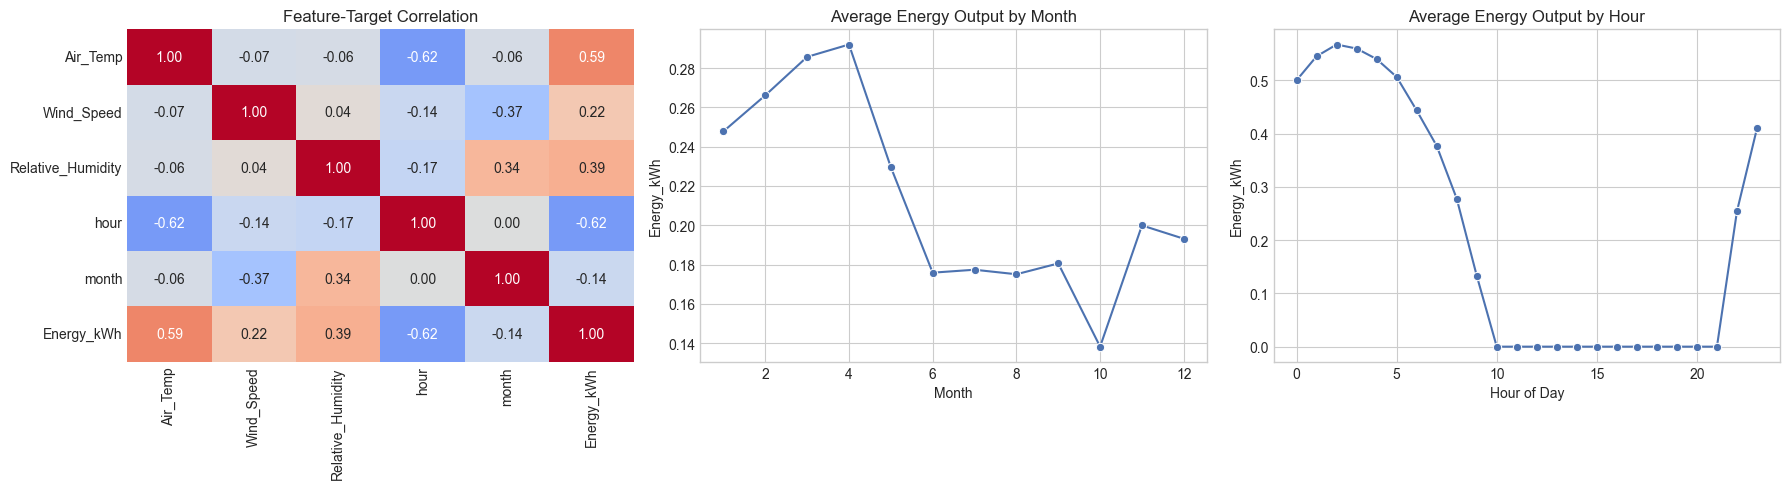

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

corr_matrix = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[0], cbar=False)
axes[0].set_title('Feature-Target Correlation')

monthly_profile = df.groupby('month')[TARGET_COLUMN].mean()
sns.lineplot(x=monthly_profile.index, y=monthly_profile.values, marker='o', ax=axes[1])
axes[1].set_title('Average Energy Output by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Energy_kWh')

hourly_profile = df.groupby('hour')[TARGET_COLUMN].mean()
sns.lineplot(x=hourly_profile.index, y=hourly_profile.values, marker='o', ax=axes[2])
axes[2].set_title('Average Energy Output by Hour')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Energy_kWh')

plt.tight_layout()
plt.show()

## 1b. Presentation Visuals

These plots make the data story easier to explain in a presentation: how the inputs relate to the target, and how PV energy changes across time.

## 2. Chronological split and scaling

The split is time-based, not random, so future observations are never used in training. Inputs and target values are then scaled with MinMaxScaler.

In [40]:
def chronological_split(frame, validation_ratio=0.15, test_ratio=0.15):
    if validation_ratio + test_ratio >= 1:
        raise ValueError('Validation and test ratios must sum to less than 1.')

    total_rows = len(frame)
    test_size = int(round(total_rows * test_ratio))
    validation_size = int(round(total_rows * validation_ratio))
    train_end = total_rows - validation_size - test_size

    if train_end <= 0:
        raise ValueError('Not enough rows to create train/validation/test splits.')

    train_df = frame.iloc[:train_end].copy()
    validation_df = frame.iloc[train_end:train_end + validation_size].copy()
    test_df = frame.iloc[train_end + validation_size:].copy()
    return train_df, validation_df, test_df

train_df, validation_df, test_df = chronological_split(df, VALIDATION_RATIO, TEST_RATIO)

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train = feature_scaler.fit_transform(train_df[FEATURE_COLUMNS])
X_val = feature_scaler.transform(validation_df[FEATURE_COLUMNS])
X_test = feature_scaler.transform(test_df[FEATURE_COLUMNS])

y_train = target_scaler.fit_transform(train_df[[TARGET_COLUMN]])
y_val = target_scaler.transform(validation_df[[TARGET_COLUMN]])
y_test = target_scaler.transform(test_df[[TARGET_COLUMN]])

X_train.shape, X_val.shape, X_test.shape

((6132, 5), (1314, 5), (1314, 5))

## 3. Build the ANN model

The model follows the requested architecture: 10 hidden units, then 8 hidden units, then a linear output neuron for regression.

In [41]:
def build_ann_model(input_dim, learning_rate=0.001):
    model = keras.Sequential([
        keras.layers.Dense(10, activation='relu', input_shape=(input_dim,)),
        keras.layers.Dropout(0.2), 
        keras.layers.Dense(8, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='linear')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model

ann_model = build_ann_model(len(FEATURE_COLUMNS), learning_rate=LEARNING_RATE)
ann_model.summary()

d:\CodingRelated\Codes.Ams\IS_RENER_PROJ\IS_PROJ\.venv_tf\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157 (628.00 B)

 Trainable params: 157 (628.00 B)

 Non-trainable params: 0 (0.00 B)


MODEL ARCHITECTURE VISUALIZATION


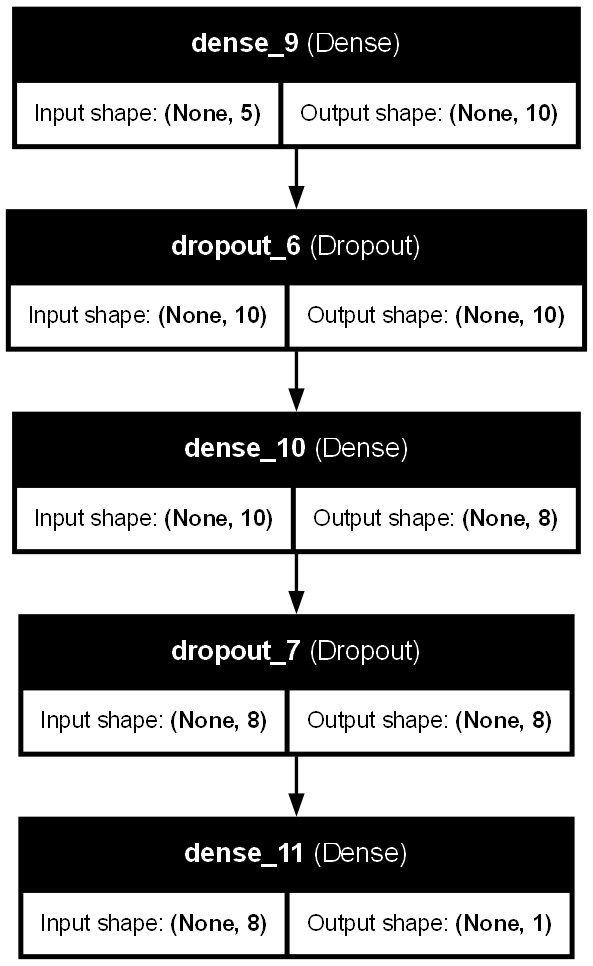

In [42]:
print("\n" + "=" * 70)
print("MODEL ARCHITECTURE VISUALIZATION")
print("=" * 70)

output_path = OUTPUT_DIR / 'model_architecture.png'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    keras.utils.plot_model(
        ann_model,
        to_file=str(output_path),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=120,
    )
    if output_path.exists():
        from IPython.display import Image, display
        display(Image(filename=str(output_path)))
    else:
        print(f"Model diagram could not be found at {output_path}.")
except Exception as exc:
    print(f"Model diagram export skipped: {exc}")


## 4. Train the ANN

EarlyStopping restores the best weights from validation loss, which helps reduce overfitting.

In [43]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1242 - mae: 0.2917 - val_loss: 0.0645 - val_mae: 0.2342
Epoch 2/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0805 - mae: 0.2350 - val_loss: 0.0391 - val_mae: 0.1671
Epoch 3/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0604 - mae: 0.1963 - val_loss: 0.0270 - val_mae: 0.1387
Epoch 4/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0508 - mae: 0.1747 - val_loss: 0.0229 - val_mae: 0.1220
Epoch 5/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0474 - mae: 0.1674 - val_loss: 0.0206 - val_mae: 0.1110
Epoch 6/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0455 - mae: 0.1610 - val_loss: 0.0204 - val_mae: 0.1139
Epoch 7/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0424 - mae: 0.1552 - val_loss: 0.0193 - val_mae: 0.1087
Epoch 8/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0407 - mae: 0.1500 - val_loss: 0.0186 - val_mae: 0.1039
Epoch 9/150
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

In [44]:
print("\n" + "=" * 70)
print("DATA SHAPES FOR TRAINING")
print("=" * 70)
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}   | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}   | y_test shape:  {y_test.shape}")
print(f"\nTraining Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Early Stopping Patience: 10")
print("=" * 70 + "\n")


DATA SHAPES FOR TRAINING
X_train shape: (6132, 5) | y_train shape: (6132, 1)
X_val shape:   (1314, 5)   | y_val shape:   (1314, 1)
X_test shape:  (1314, 5)   | y_test shape:  (1314, 1)

Training Configuration:
  Epochs: 150
  Batch Size: 32
  Learning Rate: 0.001
  Early Stopping Patience: 10



## 5. Evaluate the ANN and compare it with linear regression

Metrics are computed on the inverse-transformed test predictions so they are reported in the original kWh scale.

In [45]:
def inverse_target(values):
    return target_scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).reshape(-1)

def evaluate_predictions(y_true, y_pred):
    return {
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }

y_test_true = inverse_target(y_test)
ann_pred = inverse_target(ann_model.predict(X_test))
ann_metrics = evaluate_predictions(y_test_true, ann_pred)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train.ravel())
baseline_pred = inverse_target(baseline_model.predict(X_test))
baseline_metrics = evaluate_predictions(y_test_true, baseline_pred)

print('ANN metrics:', ann_metrics)
print('Baseline metrics:', baseline_metrics)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
ANN metrics: {'rmse': 0.15928065432230917, 'mae': 0.11454959852889658, 'r2': 0.6213696860147471}
Baseline metrics: {'rmse': 0.1720559971326354, 'mae': 0.1263301940192603, 'r2': 0.5581967064438811}


In [46]:
print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

results_table = pd.DataFrame({
    'Model': ['ANN', 'Linear Regression'],
    'RMSE': [f"{ann_metrics['rmse']:.4f}", f"{baseline_metrics['rmse']:.4f}"],
    'MAE': [f"{ann_metrics['mae']:.4f}", f"{baseline_metrics['mae']:.4f}"],
    'R² Score': [f"{ann_metrics['r2']:.4f}", f"{baseline_metrics['r2']:.4f}"]
})
print(results_table.to_string(index=False))

improvement_rmse = ((baseline_metrics['rmse'] - ann_metrics['rmse']) / baseline_metrics['rmse']) * 100
improvement_r2 = ((ann_metrics['r2'] - baseline_metrics['r2']) / baseline_metrics['r2']) * 100 if baseline_metrics['r2'] > 0 else 0

print(f"\nANN Improvement over Baseline:")
print(f"  RMSE:   {improvement_rmse:+.2f}% {'better' if improvement_rmse > 0 else 'worse'}")
print(f"  R² Score: {improvement_r2:+.2f}% {'better' if improvement_r2 > 0 else 'worse'}")
print("=" * 70)

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE (Correlation with Target)")
print("=" * 70)
feature_corr = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Correlation': [df[feat].corr(df[TARGET_COLUMN]) for feat in FEATURE_COLUMNS]
}).sort_values('Correlation', key=abs, ascending=False)

for idx, row in feature_corr.iterrows():
    bar = '█' * int(abs(row['Correlation']) * 50)
    print(f"{row['Feature']:20s}: {row['Correlation']:7.4f}  {bar}")
print("=" * 70)


MODEL PERFORMANCE COMPARISON
            Model   RMSE    MAE R² Score
              ANN 0.1593 0.1145   0.6214
Linear Regression 0.1721 0.1263   0.5582

ANN Improvement over Baseline:
  RMSE:   +7.43% better
  R² Score: +11.32% better

FEATURE IMPORTANCE (Correlation with Target)
hour                : -0.6196  ██████████████████████████████
Air_Temp            :  0.5915  █████████████████████████████
Relative_Humidity   :  0.3855  ███████████████████
Wind_Speed          :  0.2176  ██████████
month               : -0.1352  ██████


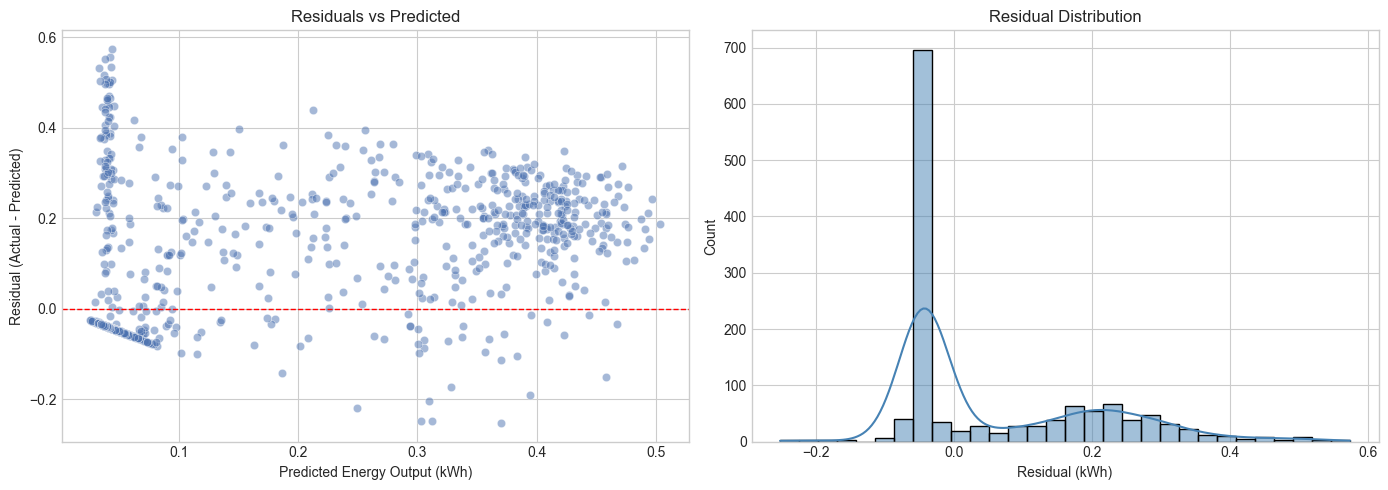

In [50]:
residuals = y_test_true - ann_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=ann_pred, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Energy Output (kWh)')
axes[0].set_ylabel('Residual (Actual - Predicted)')

sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (kWh)')

plt.tight_layout()
plt.show()

## 6. Visualize results and save the trained model

The plots below show training behavior and predicted-vs-actual performance. The trained ANN is also saved to disk as an `.h5` file.


VISUALIZATION: TRAINING HISTORY & PREDICTIONS



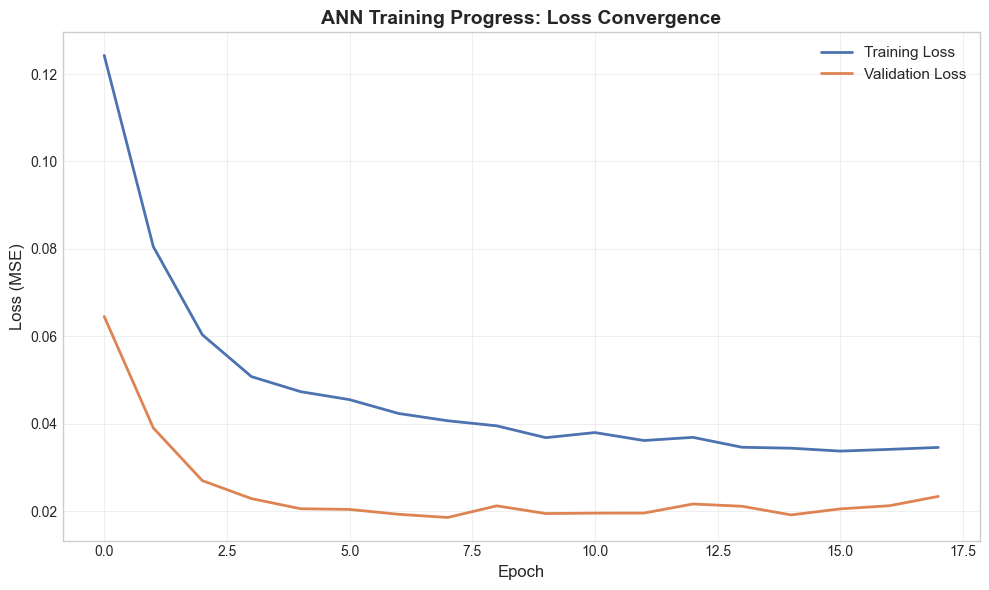

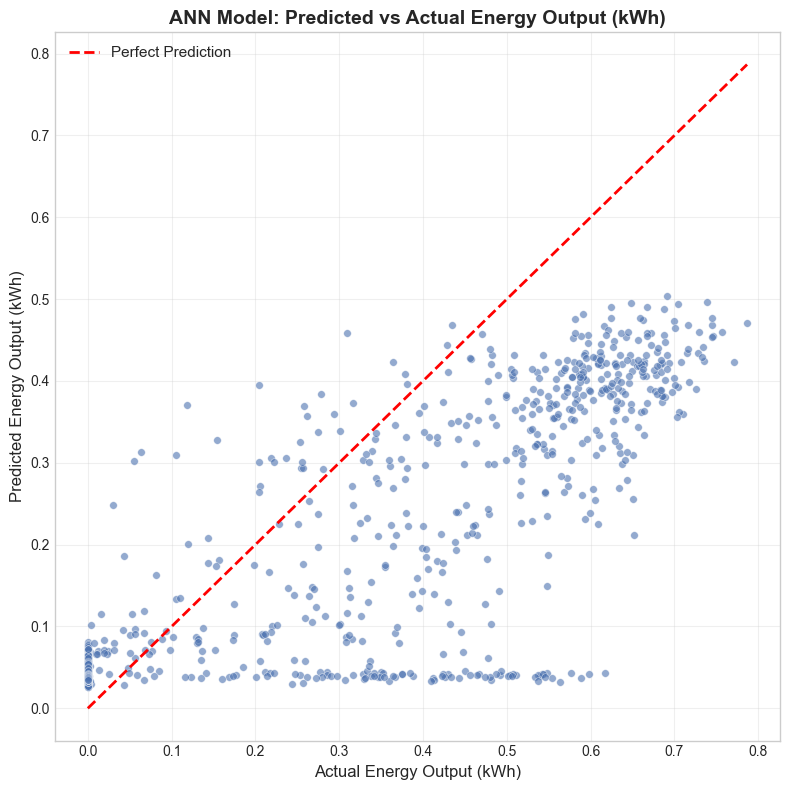

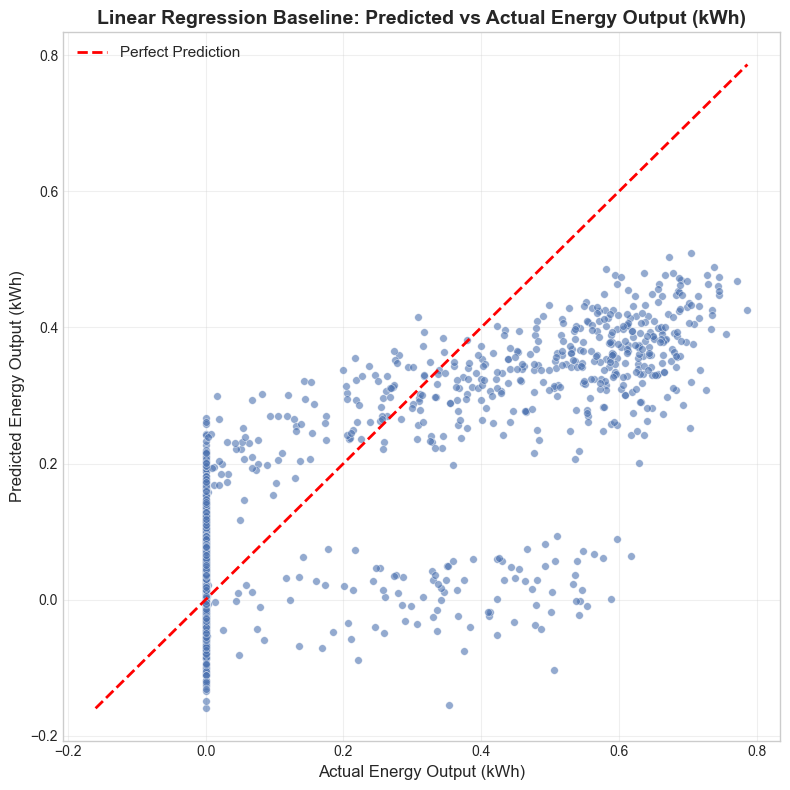

Saved model to artifacts\ann_model.h5


In [47]:
def plot_training_history(history_obj):
    plt.figure(figsize=(10, 6))
    plt.plot(history_obj.history['loss'], label='Training Loss', linewidth=2)
    if 'val_loss' in history_obj.history:
        plt.plot(history_obj.history['val_loss'], label='Validation Loss', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title('ANN Training Progress: Loss Convergence', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_predicted_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(8, 8))
    sns.scatterplot(x=y_true, y=y_pred, s=30, alpha=0.6)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r--', linewidth=2, label='Perfect Prediction')
    plt.xlabel('Actual Energy Output (kWh)', fontsize=12)
    plt.ylabel('Predicted Energy Output (kWh)', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("VISUALIZATION: TRAINING HISTORY & PREDICTIONS")
print("=" * 70 + "\n")

plot_training_history(history)
plot_predicted_vs_actual(y_test_true, ann_pred, 'ANN Model: Predicted vs Actual Energy Output (kWh)')
plot_predicted_vs_actual(y_test_true, baseline_pred, 'Linear Regression Baseline: Predicted vs Actual Energy Output (kWh)')

model_path = OUTPUT_DIR / 'ann_model.h5'
ann_model.save(model_path)
print(f'Saved model to {model_path}')

## 7. Summary

In [48]:
import math

def _inv(arr):
    try:
        return target_scaler.inverse_transform(np.asarray(arr).reshape(-1, 1)).reshape(-1)
    except Exception:
        return None

def _compute_metrics(model):
    if model is None or 'X_test' not in globals() or 'y_test' not in globals():
        return {'rmse': math.nan, 'mae': math.nan, 'r2': math.nan}
    try:
        y_true = _inv(y_test)
        y_pred = _inv(model.predict(X_test))
        return evaluate_predictions(y_true, y_pred) if (y_true is not None and y_pred is not None) else {'rmse': math.nan, 'mae': math.nan, 'r2': math.nan}
    except Exception:
        return {'rmse': math.nan, 'mae': math.nan, 'r2': math.nan}

# Always recompute to avoid stale metrics from previous target definitions
ann_metrics = _compute_metrics(globals().get('ann_model'))
baseline_metrics = _compute_metrics(globals().get('baseline_model'))

ann_rmse = ann_metrics.get('rmse', math.nan)
ann_mae = ann_metrics.get('mae', math.nan)
ann_r2 = ann_metrics.get('r2', math.nan)
baseline_rmse = baseline_metrics.get('rmse', math.nan)

improvement_rmse = ((baseline_rmse - ann_rmse) / baseline_rmse * 100) if (baseline_rmse and not math.isnan(baseline_rmse) and baseline_rmse > 0) else 0.0

try:
    feature_corr = pd.DataFrame({
        'Feature': FEATURE_COLUMNS,
        'Correlation': [df[f].corr(df[TARGET_COLUMN]) for f in FEATURE_COLUMNS]
    }).sort_values('Correlation', key=abs, ascending=False)
    top_feat = f"{feature_corr.iloc[0]['Feature']} (r={feature_corr.iloc[0]['Correlation']:.4f})"
except Exception:
    top_feat = 'n/a'

lines = [
    "=" * 70,
    "PROJECT SUMMARY & CONCLUSIONS",
    "=" * 70,
    f"Goal achieved: Predicting {TARGET_COLUMN} from weather/time features",
    f"Samples: {df.shape[0] if 'df' in globals() else 'n/a'}",
    f"Features: {', '.join(FEATURE_COLUMNS)}",
    "",
    "Architecture: 10 -> 8 -> 1, dropout 20%, Adam, MSE",
    "",
    f"ANN RMSE: {ann_rmse:.4f} kWh",
    f"ANN MAE:  {ann_mae:.4f} kWh",
    f"ANN R2:   {ann_r2:.4f}",
    f"Baseline RMSE: {baseline_rmse:.4f} kWh",
    f"RMSE improvement vs baseline: {improvement_rmse:.2f}%",
    "",
    f"Top correlated feature: {top_feat}",
    "=" * 70,
]
print("\n".join(lines))


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
PROJECT SUMMARY & CONCLUSIONS
Goal achieved: Predicting Energy_kWh from weather/time features
Samples: 8760
Features: Air_Temp, Wind_Speed, Relative_Humidity, hour, month

Architecture: 10 -> 8 -> 1, dropout 20%, Adam, MSE

ANN RMSE: 0.1593 kWh
ANN MAE:  0.1145 kWh
ANN R2:   0.6214
Baseline RMSE: 0.1721 kWh
RMSE improvement vs baseline: 7.43%

Top correlated feature: hour (r=-0.6196)
